/Users/siddharthsrivastava/.pyenv/versions/3.10.12/lib/python3.10/site-packages/torch/nn/modules/loss.py:128: UserWarning: Using a target size (torch.Size([501])) that is different to the input size (torch.Size([501, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Epoch 0/1000, Loss: 0.725904
Epoch 25/1000, Loss: 0.653430
Epoch 50/1000, Loss: 0.628446
Epoch 75/1000, Loss: 0.630392
Epoch 100/1000, Loss: 0.631950
Epoch 125/1000, Loss: 0.633814
Epoch 150/1000, Loss: 0.627384
Epoch 175/1000, Loss: 0.629775
Epoch 200/1000, Loss: 0.627397
Epoch 225/1000, Loss: 0.627642
Epoch 250/1000, Loss: 0.633162
Epoch 275/1000, Loss: 0.627880
Epoch 300/1000, Loss: 0.627532
Epoch 325/1000, Loss: 0.628132
Epoch 350/1000, Loss: 0.627033
Epoch 375/1000, Loss: 0.627039
Epoch 400/1000, Loss: 0.627738
Epoch 425/1000, Loss: 0.629095
Epoch 450/1000, Loss: 0.627647
Epoch 475/1000, Loss: 0.627557
Epoch 500/1000, Loss: 0.628240
Epoch 525/1000, Loss: 0.627332
Epoch 550/1000, Loss: 0.629107
Epoch 575/1000, Loss: 0.627944
Epoch 600/1000, Loss: 0.627234
Epoch 625/1000, Loss: 0.627185
Epoch 650/1000, Loss: 0.627677
Epoch 675/1000, Loss: 0.627510
Epoch 700/1000, Loss: 0.627827
Epoch 725/1000, Loss: 0.627507
Epoch 750/1000, Loss: 0.627860
Epoch 775/1000, Loss: 0.627390
Epoch 800/100

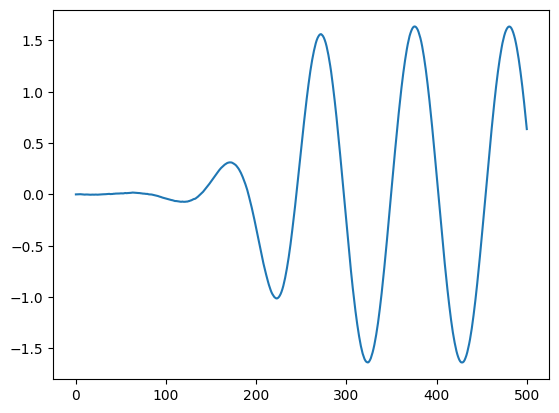

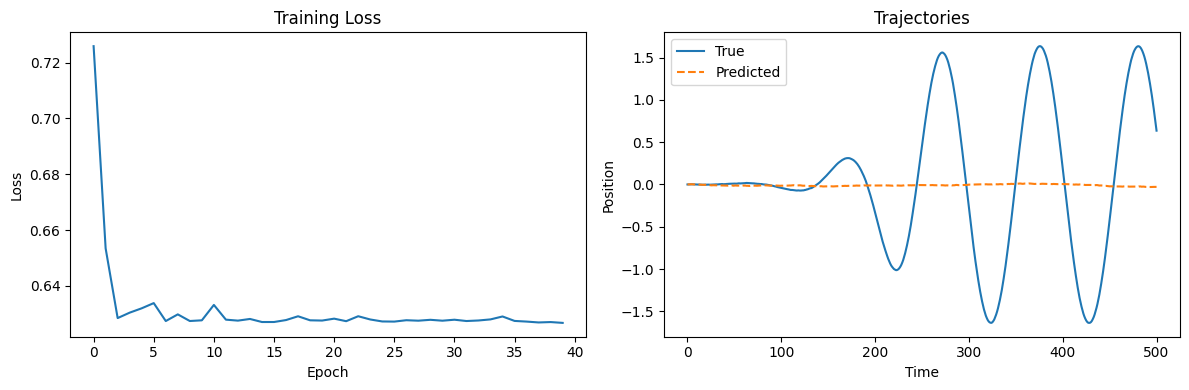


Final Parameters:
Learned a: -0.410, Ground Truth: 2.5
Learned omega: 1.142, Ground Truth: 6.0
Learned beta: 1.000, Ground Truth: 1.0


In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

seed = 42
np.random.seed(seed)

def dXdt(Xt, Yt, a, omega):
    return (a - Xt**2 - Yt**2) * Xt - omega * Yt + np.random.normal(0, 0.1)

def dYdt(Xt, Yt, a, omega):
    return (a - Xt**2 - Yt**2) * Yt + omega * Xt + np.random.normal(0, 0.1)


class SLOscillator(nn.Module):
    def __init__(self, dt):
        super().__init__()
        self.dt = dt

        self.a = nn.Parameter(torch.tensor(1.0))
        self.omega = nn.Parameter(torch.tensor(1.0))
        self.beta = nn.Parameter(torch.tensor(1.0))


    def forward(self, ts):
        X = [torch.tensor([0.0])]
        Y = [torch.tensor([0.0])]

        for t in range(ts - 1):
            Xtp = X[t] + self.dt*(dXdt(X[t], Y[t], self.a, self.omega))
            Ytp = Y[t] + self.dt*(dYdt(X[t], Y[t], self.a, self.omega))

            X.append(Xtp)
            Y.append(Ytp)

        return torch.stack(X)


def generate_data(T, dt, a, omega, beta):
    np.random.seed(42)
    Ts = np.arange(0, T + dt, dt)

    X = [0.0]
    Y = [0.0]

    for t in range(len(Ts) - 1):
        Xtp = X[t]+ dt*(dXdt(X[t], Y[t], a, omega))
        Ytp = Y[t]+ dt*(dYdt(X[t], Y[t], a, omega))

        X.append(Xtp)
        Y.append(Ytp)

    return np.stack(X)

T, dt = 5.0, 0.01
a, omega, beta = 2.5, 6.0, 1.0
true_trajectory = torch.tensor(generate_data(T, dt, a, omega, beta), dtype=torch.float32)

plt.plot(true_trajectory)

model = SLOscillator(dt)
optim = torch.optim.Adam(model.parameters(), 1e-2)

criterion = nn.L1Loss()
epochs = 1000

losses = []
for epoch in range(epochs):
    optim.zero_grad()

    pred_traj = model(len(true_trajectory))

    loss = criterion(pred_traj, true_trajectory)

    loss.backward()
    optim.step()

    if epoch % 25 == 0:
        losses.append(loss.item())
        print(f'Epoch {epoch}/{epochs}, Loss: {loss.item():.6f}')

plt.figure(figsize=(12, 4))

plt.subplot(121)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')

plt.subplot(122)
plt.plot(true_trajectory.detach().numpy(), label='True')
plt.plot(pred_traj.detach().numpy(), '--', label='Predicted')
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Trajectories')
plt.legend()

plt.tight_layout()
plt.show()


print("\nFinal Parameters:")
print(f"Learned a: {model.a.item():.3f}, Ground Truth: {a}")
print(f"Learned omega: {model.omega.item():.3f}, Ground Truth: {omega}")
print(f"Learned beta: {model.beta.item():.3f}, Ground Truth: {beta}")